## Data Overview

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/synthetic_medical_triage.csv")
df.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  object 
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 1.4+ MB


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,triage_level
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,44.716244,83.292322,128.072739,96.085183,37.224236,3.402111,1.072611,1.265056,0.697722
std,19.101056,16.964405,18.813277,3.330830,0.914978,2.039249,1.312204,1.454887,0.898923
min,0.000000,33.400000,65.800000,79.500000,34.470000,1.000000,0.000000,0.000000,0.000000
25%,31.200000,71.500000,114.900000,94.300000,36.580000,2.000000,0.000000,0.000000,0.000000
50%,44.000000,81.600000,126.900000,96.600000,37.120000,3.000000,1.000000,1.000000,0.000000
75%,57.500000,93.200000,139.900000,98.700000,37.770000,5.000000,2.000000,2.000000,1.000000
max,95.000000,152.300000,219.700000,100.000000,41.130000,10.000000,10.000000,11.000000,3.000000


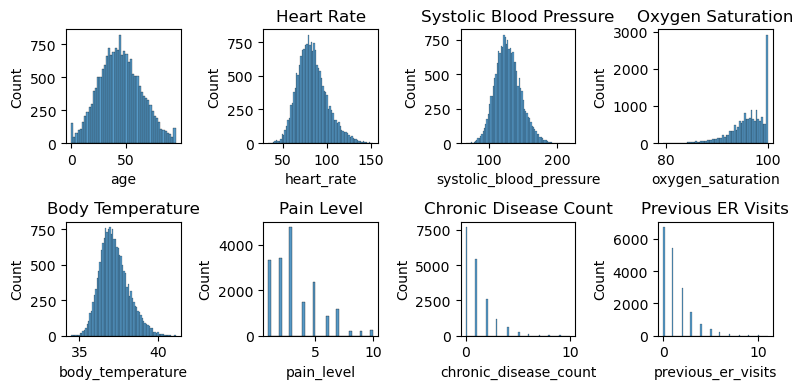

In [9]:
fig, axes = plt.subplots(2,4, figsize=(8,4))

sns.histplot(df["age"], ax=axes[0,0])

sns.histplot(df["heart_rate"], ax=axes[0,1])
axes[0,1].set_title("Heart Rate")

sns.histplot(df["systolic_blood_pressure"], ax=axes[0,2])
axes[0,2].set_title("Systolic Blood Pressure")

sns.histplot(df["oxygen_saturation"], ax=axes[0,3])
axes[0,3].set_title("Oxygen Saturation")

sns.histplot(df["body_temperature"], ax=axes[1,0])
axes[1,0].set_title("Body Temperature")

sns.histplot(df["pain_level"], ax=axes[1,1])
axes[1,1].set_title("Pain Level")

sns.histplot(df["chronic_disease_count"], ax=axes[1,2])
axes[1,2].set_title("Chronic Disease Count")

sns.histplot(df["previous_er_visits"], ax=axes[1,3])
axes[1,3].set_title("Previous ER Visits")

plt.tight_layout()
plt.show()

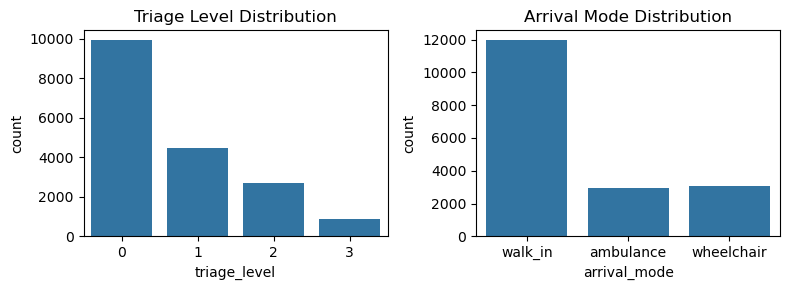

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8,3))

sns.countplot(x="triage_level", data=df, ax=axes[0])
axes[0].set_title("Triage Level Distribution")

sns.countplot(x="arrival_mode", data=df, ax=axes[1])
axes[1].set_title("Arrival Mode Distribution")

plt.tight_layout()
plt.show()

## Data Quality Check

In the preprocess stage, the quality of the data must be checked, including:
* Handle missing data
* Remove duplicate data
* Correcting data types
* Handle outliers
* Encoding categorical variables
* Feature scaling/normalization/standardization
* Remove irrelevant features
* Feature engineering
* Splitting data into training/testing sets

In [15]:
df.isnull().sum()

age                        0
heart_rate                 0
systolic_blood_pressure    0
oxygen_saturation          0
body_temperature           0
pain_level                 0
chronic_disease_count      0
previous_er_visits         0
arrival_mode               0
triage_level               0
dtype: int64

The dataset contains no missing values, so no row removal was required. The rest of the bullet points can be found in the preprocess.py file.

## Results

* Precision: of all patients predicted as this class, how many were correct?
* Recall: of all actual patients in this class, how many did the model identify correctly?
* F1-score: harmonic mean of precision and recall (balances both)
* Support: number of samples in the test set for this class 

### Results of one run

<table>
  <tr>
    <th>Class</th>
    <th>Precision</th>
    <th>Recall</th>
    <th>F1-score</th>
    <th>Support</th>
  </tr>
  <tr>
    <td>0</td>
    <td>0.92</td>
    <td>0.98</td>
    <td>0.95</td>
    <td>2020</td>
  </tr>
  <tr>
    <td>1</td>
    <td>0.88</td>
    <td>0.74</td>
    <td>0.80</td>
    <td>873</td>
  </tr>
  <tr>
    <td>2</td>
    <td>0.72</td>
    <td>0.90</td>
    <td>0.80</td>
    <td>534</td>
  </tr>
  <tr>
    <td>3</td>
    <td>0.90</td>
    <td>0.32</td>
    <td>0.48</td>
    <td>173</td>
  </tr>
</table>

<table>
  <tr>
    <th>Accuracy</th>
    <th>-</th>
    <th>-</th>
    <th>0.88</th>
    <th>3600</th>
  </tr>
  <tr>
    <th>Macro Avg</th>
    <th>0.86</th>
    <th>0.74</th>
    <th>0.76</th>
    <th>3600</th>
  </tr>
  <tr>
    <th>Weighted Avg</th>
    <th>0.88</th>
    <th>0.88</th>
    <th>0.87</th>
    <th>3600</th>
  </tr>
</table>


* Class 0 (low triage): Excellent performance. Most are correctly classified
* Class 3 (highest triage): Recall is low (0.32) meaning model misses many critical patients
Insight: This model favors predicting the more common classes such as class 0 and class 1, likely because the datasets are imbalanced (see support: 2020 vs 173).

The neural network achieves 88% overall acuracy. However, precision and recall were high for the most common triage level (class 0), but recall drops for class 3. This could suggest that while the model performs well overall, it may under-predict critical patients, highlighting the need for potential dataset balancing or class weighting. 

## Future Work/Improvements

* Incorporate class weighting or oversampling techniques to improve recall for high-priority patients
* Collect additional data or use real-world datasets to enhance model generalization and performance
* Evaluate model predictions using more robust healthcare metrics such as sensitivity for high-priority patients
* Create a deeper neural network to handle more datasets and improve accuracy